## Module-11 Multiple_Linear_Regression

### 11.1 Intro to Multiple Linear Regression

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [83]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])

# w =[5,10,-2,0.5] , b=2.0
y = np.array([45.9 ,  76.55,  92.35, 107.9 , 128. ])

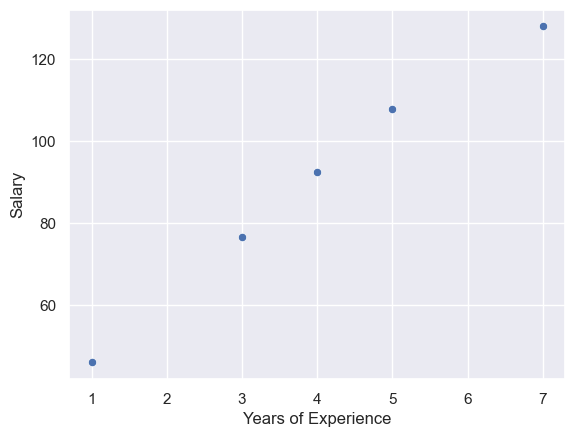

In [84]:
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
sns.scatterplot(x=X[:,0:1].ravel(),y=y)
plt.show()

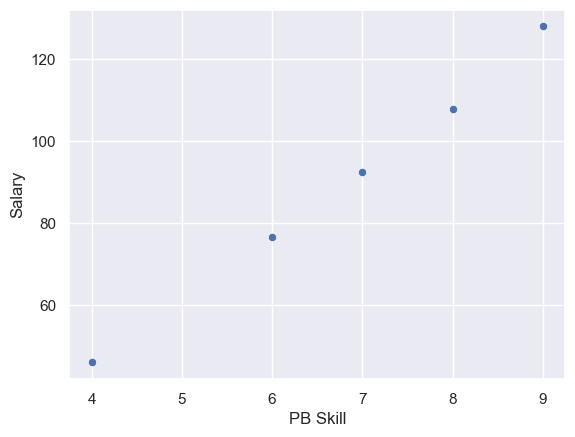

In [85]:
plt.xlabel("PB Skill")
plt.ylabel("Salary")
sns.scatterplot(x=X[:,1:2].ravel(),y=y)
plt.show()

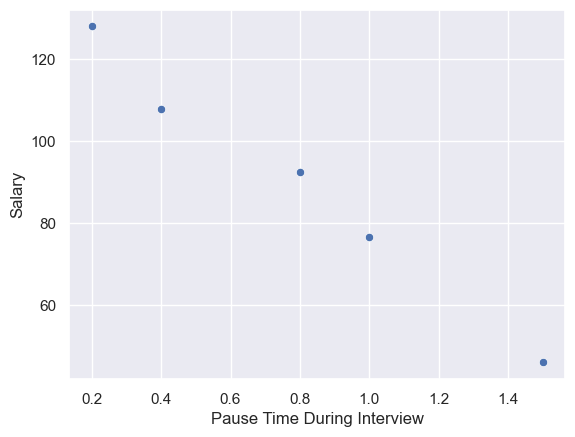

In [86]:
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
sns.scatterplot(x=X[:,2:3].ravel(),y=y)
plt.show()

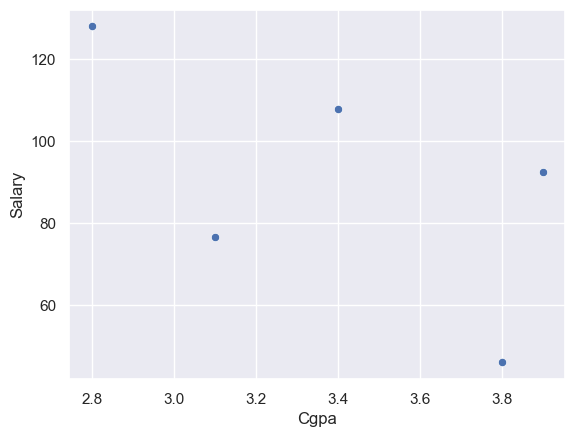

In [87]:
plt.xlabel("Cgpa")
plt.ylabel("Salary")
sns.scatterplot(x=X[:,3:].ravel(),y=y)
plt.show()

### 11.5 Implementation of Prediction function

In [88]:
def make_prediction(X,y,W,b): 
    m= X.shape[0]

    pred_list = np.zeros((m,)) 

    for i in range(m): 
        # X[i] = feature vector & W = weight vector
        pred_list[i] = np.dot(W,X[i]) + b

    return pred_list 

In [89]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0 

make_prediction(X,y,W_init,b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

## 11.7 Cost function formulization and implementation

In [90]:
def compute_cost(X,y,W,b): 
    m = X.shape[0] 
    cost = 0.0 

    pred_list = make_prediction(X,y,W,b) 
    #print(pred_list)

    error = pred_list - y
    #print(error)
    error_squared = error ** 2
    #print(error_squared)
    cost = np.sum(error_squared)
    cost = cost / (2*m)

    return cost



In [91]:

W_init = np.ones((n,))
b_init = 1.0 

compute_cost(X,y,W_init,b_init)

np.float64(3060.2095)

### 11.9 Calculating Gradient P-2

In [92]:
def calculate_gradient(X,y,W,b): 
    m = X.shape[0]
    n = X.shape[1]

    dj_dw = np.zeros((n,))
    dj_db = 0.0 

    for i in range(m): 
        prediction = np.dot(W,X[i]) + b
        error = prediction - y[i] 

        for j in range(n): 
            dj_dw[j] = dj_dw[j] +(error * X[i,j])

    return dj_dw / m, dj_db / m
            

In [93]:
W_init = np.ones((n,))
b_init = 1.0 
calculate_gradient(X,y,W_init,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), 0.0)

### 11.10 Calculating Gradient P-3

In [94]:
def calculate_gradient(X,y,W,b): 
    m = X.shape[0]
    n = X.shape[1]

    dj_dw = np.zeros((n,))
    dj_db = 0.0 

    for i in range(m): 
        prediction = np.dot(W,X[i]) + b
        error = prediction - y[i] 
        dj_db = dj_db + error

        for j in range(n): 
            dj_dw[j] = dj_dw[j] +(error * X[i,j])
            
    return dj_dw / m, dj_db / m
            

In [95]:
W_init = np.ones((n,))
b_init = 1.0 
calculate_gradient(X,y,W_init,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

### 11.11 Cost Optimization using Gradient Descent

In [96]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])

make_prediction(X,y,W=[5,10,-2,0.5],b=2)

array([ 45.9 ,  76.55,  92.35, 107.9 , 128.  ])

In [103]:
def gradient_descent(X,y,w_input,b_input,max_iter,alpha=0.01): 
    
    w = w_input 
    b = b_input 
    cost_memo = []
    iteration = []
    for i in range(max_iter): 
        dj_dw,dj_db = calculate_gradient(X,y,w,b) 

        #update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db 

        cost = compute_cost(X,y,w,b)

        cost_memo.append(cost) 
        iteration.append(i)

        if i%100 == 0: 
            print(f"Iteration:{i}: cost:{cost:0.4f}, dj_dw:{dj_dw}, dj_db:{dj_db:} w:{w}, b:{b:0.4f}") 

    return w,b,cost_memo, iteration

In [104]:
W_init = np.zeros((n,))
b_init = 0.0 
w_final,b_final,cost_memo,iter = gradient_descent(X,y,w_input=W_init, b_input=b_init, max_iter=10000,alpha=0.01)

Iteration:0: cost:188.4458, dj_dw:[-416.09  -660.91   -57.608 -299.43 ], dj_db:-90.14 w:[4.1609  6.6091  0.57608 2.9943 ], b:0.9014
Iteration:100: cost:0.1977, dj_dw:[-0.28972633 -0.05290958  0.24653403  0.43027154], dj_db:0.08612436152810829 w:[ 6.8215041   8.3071171  -0.38008643  1.775159  ], b:0.7104
Iteration:200: cost:0.1303, dj_dw:[ 0.02982799 -0.05138487  0.04097921  0.06083368], dj_db:0.007027042739039757 w:[ 6.88604616  8.35924356 -0.48209566  1.60468101], b:0.6799
Iteration:300: cost:0.1229, dj_dw:[ 0.05097646 -0.04994653  0.0258774   0.03389236], dj_db:0.0014341624474738524 w:[ 6.84103994  8.40989801 -0.51257454  1.56262078], b:0.6769
Iteration:400: cost:0.1162, dj_dw:[ 0.05111217 -0.04855146  0.02422668  0.0311383 ], dj_db:0.0010265453320059236 w:[ 6.7896808   8.45913669 -0.53741432  1.53048588], b:0.6757
Iteration:500: cost:0.1098, dj_dw:[ 0.04980317 -0.04719556  0.0235398   0.03011513], dj_db:0.0009845325017124652 w:[ 6.7392106   8.50700022 -0.56127851  1.49989217], b:0.6

In [105]:
print(w_final) 
print(b_final)

[ 5.09106003 10.05932782 -1.39677804  0.53587985]
0.6397670641047858


In [108]:
X_test = [2,10,1.5,3.8]

prediction_of_new_data = w_final[0] * X_test[0] + w_final[1] * X_test[1] + w_final[2] * X_test[2] + w_final[3] * X_test[3] + b_final 

print(prediction_of_new_data)

111.35634168930196


### 11.12 Implementation through scikit learn

#### Linear Regression using sckit learn

In [110]:

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [111]:
model1 = LinearRegression()

model1.fit(X,y) 


weights = model1.coef_ 
bias = model1.intercept_ 

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000213


#### SGD regressor 

In [116]:
model2 = SGDRegressor(penalty=None,max_iter=10000,learning_rate="constant") 

model2.fit(X,y) 

weights = model2.coef_ 
bias = model2.intercept_  

print(weights)
print(bias)

[ 5.98836313  9.15970889 -0.94870859  1.09900279]
[0.68022784]
